# Exploratory Data Analysis - servir_jobs_transformed.db
Basic exploration: shape, nulls, variables, descriptive statistics

In [10]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Absolute path - works from anywhere
project_root = Path("/Users/francosebastiani/Documents/GitHub/Peruvian-Civil-Service-Hiring-Patterns-Analysis")
db_path = project_root / "servir" / "data" / "transformed" / "servir_jobs_transformed.db"

print(f"Project root: {project_root}")
print(f"DB path: {db_path}")
print(f"DB exists: {db_path.exists()}")

# Load data
print("Loading transformed data...")
conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM transformed_jobs", conn)
conn.close()

print(f"✓ Loaded {len(df):,} job postings")

Project root: /Users/francosebastiani/Documents/GitHub/Peruvian-Civil-Service-Hiring-Patterns-Analysis
DB path: /Users/francosebastiani/Documents/GitHub/Peruvian-Civil-Service-Hiring-Patterns-Analysis/servir/data/transformed/servir_jobs_transformed.db
DB exists: True
Loading transformed data...
✓ Loaded 21,575 job postings


=============================================================================
## 1. BASIC SHAPE AND STRUCTURE
=============================================================================

In [11]:
print(f"\nRows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Column types
print("\nColumn types:")
print(df.dtypes.value_counts())


Rows: 21,575
Columns: 79

Memory usage: 51.91 MB

Column types:
float64    48
object     22
int64       9
Name: count, dtype: int64


=============================================================================
## 2. VARIABLE INVENTORY
=============================================================================

In [12]:
print("\n" + "="*80)
print("2. AVAILABLE VARIABLES")
print("="*80)

# Group columns by category
original_cols = ['id', 'posting_unique_id', 'job_title', 'institution', 
                 'posting_start_date', 'posting_end_date', 'salary_amount',
                 'number_of_vacancies', 'contract_type', 'experience_requirements',
                 'academic_profile', 'specialization', 'knowledge', 'competencies']

matching_cols = [c for c in df.columns if 'isco' in c.lower() or 'ejecutora' in c.lower() 
                 or 'programa' in c.lower() or 'sector' in c.lower() or 'pliego' in c.lower()]

parsed_cols = [c for c in df.columns if 'years' in c.lower() or 'required' in c.lower() 
               or 'regime' in c.lower() or 'temporal' in c.lower() or 'thesis' in c.lower()]

topic_cols = [c for c in df.columns if 'topic' in c.lower()]

print(f"\nOriginal columns: {len([c for c in original_cols if c in df.columns])}")
print(f"Matching columns (ISCO, MEF, CLASIFICADOR): {len(matching_cols)}")
print(f"Parsed columns (structured extraction): {len(parsed_cols)}")
print(f"Topic columns (LDA): {len(topic_cols)}")


2. AVAILABLE VARIABLES

Original columns: 14
Matching columns (ISCO, MEF, CLASIFICADOR): 8
Parsed columns (structured extraction): 7
Topic columns (LDA): 45


=============================================================================
## 3. NULL ANALYSIS
=============================================================================


Columns with missing data (>0%):
                   Column  Missing  Percent
experience_specific_years    18448     85.5
 experience_general_years    16621     77.0
   campo_detallado_codigo    14447     67.0
          programa_codigo    14447     67.0
                isco_code     4311     20.0
         ejecutora_nombre     3831     17.8
                ejecutora     3831     17.8
                 sec_ejec     3831     17.8
                   pliego     3831     17.8
                   sector     3831     17.8
           nivel_gobierno     3831     17.8


<Figure size 1200x600 with 0 Axes>

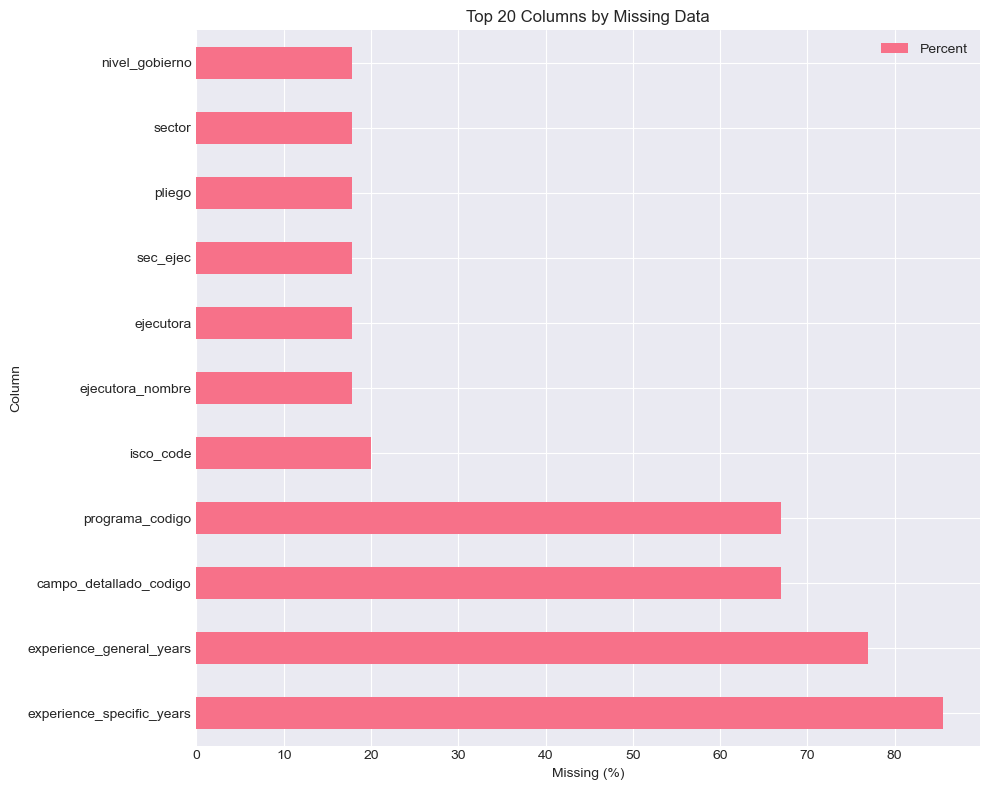

In [14]:
null_counts = df.isnull().sum()
null_pcts = (null_counts / len(df) * 100).round(1)

print("\nColumns with missing data (>0%):")
missing_df = pd.DataFrame({
    'Column': null_counts[null_counts > 0].index,
    'Missing': null_counts[null_counts > 0].values,
    'Percent': null_pcts[null_counts > 0].values
}).sort_values('Percent', ascending=False)

print(missing_df.to_string(index=False))

# Visualize missingness
plt.figure(figsize=(12, 6))
missing_df.head(20).plot(x='Column', y='Percent', kind='barh', figsize=(10, 8))
plt.xlabel('Missing (%)')
plt.title('Top 20 Columns by Missing Data')
plt.tight_layout()
plt.savefig(project_root / "servir" / "data" / "analysed" / "output" / "missing_data.png", dpi=300, bbox_inches='tight')
plt.show()

=============================================================================
## 4. DESCRIPTIVE STATISTICS - NUMERIC VARIABLES
=============================================================================



Numeric variables: 57

Key numeric variables summary:
       salary_amount  number_of_vacancies  experience_general_years  \
count   21575.000000         21575.000000               4954.000000   
mean     3607.285695             2.529316                  3.667945   
std      9002.477435            59.295949                113.912138   
min         1.000000             1.000000                  0.000000   
25%      2000.000000             1.000000                  1.000000   
50%      2900.000000             1.000000                  2.000000   
75%      4000.000000             1.000000                  3.000000   
max    636419.000000          6624.000000               8019.000000   

       experience_specific_years  
count                3127.000000  
mean                    4.032939  
std                   143.381223  
min                     0.000000  
25%                     1.000000  
50%                     1.000000  
75%                     2.000000  
max                  8019

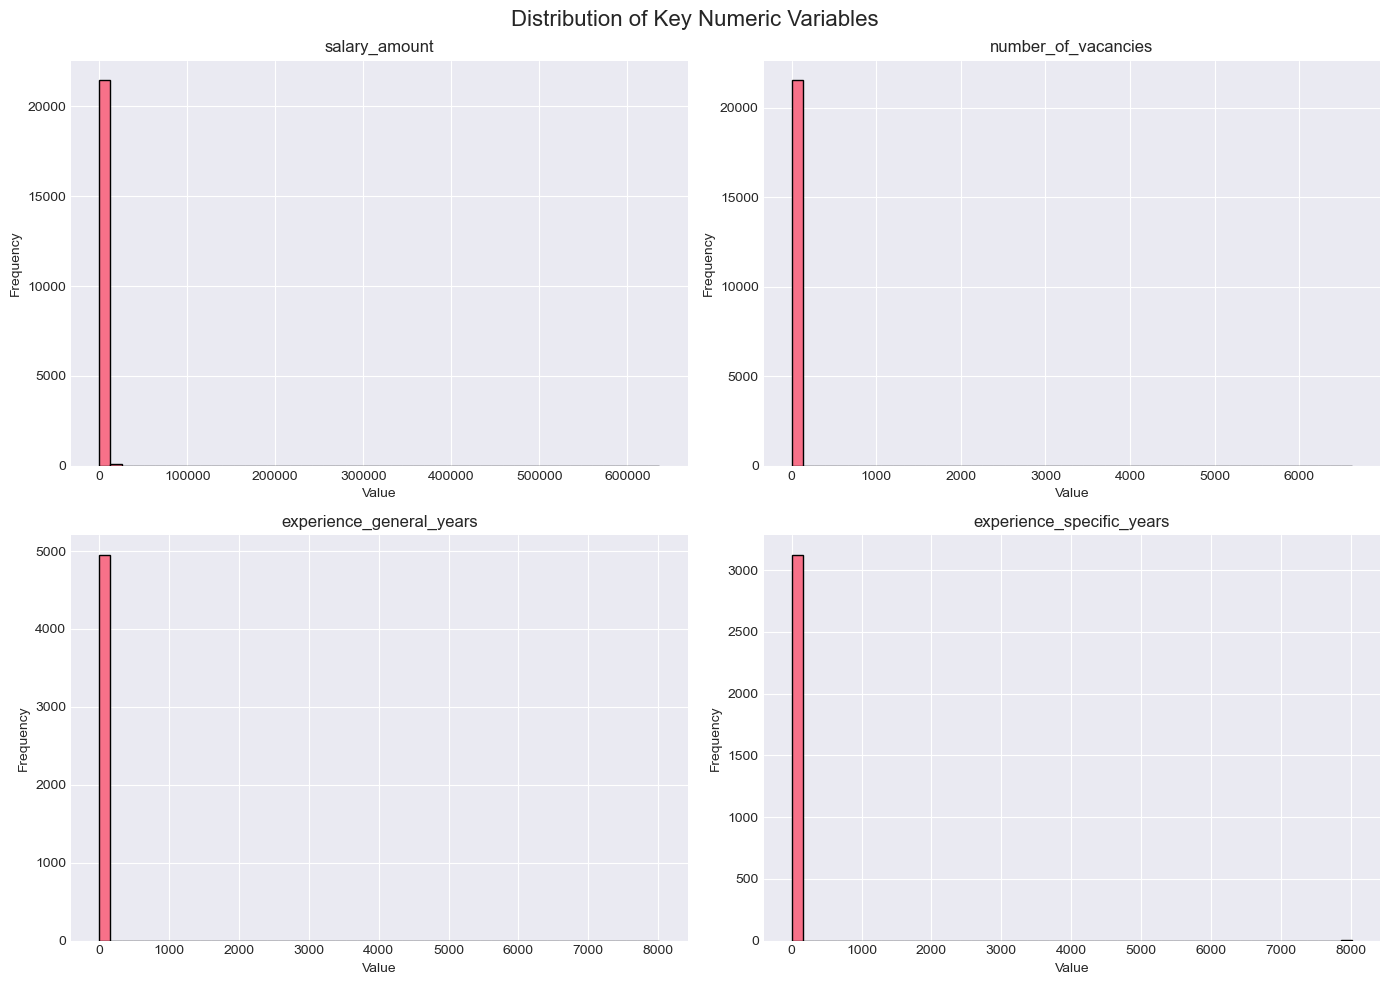

In [18]:
# Identify numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nNumeric variables: {len(numeric_cols)}")

# Key numeric variables (non-topic)
key_numeric = ['salary_amount', 'number_of_vacancies', 
               'experience_general_years', 'experience_specific_years']

print("\nKey numeric variables summary:")
print(df[key_numeric].describe())

# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Numeric Variables', fontsize=16)

for idx, col in enumerate(key_numeric):
    ax = axes[idx // 2, idx % 2]
    df[col].hist(bins=50, ax=ax, edgecolor='black')
    ax.set_title(f'{col}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(project_root / "servir" / "data" / "analysed" / "output" / "numeric_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

In [21]:
print("=== SALARY OUTLIERS ===")
print(df[df['salary_amount'] > 50000][['job_title', 'institution', 'salary_amount']].sort_values('salary_amount', ascending=False).head(10))

print("\n=== VACANCIES OUTLIERS ===")
print(df[df['number_of_vacancies'] > 100][['job_title', 'institution', 'number_of_vacancies']].sort_values('number_of_vacancies', ascending=False).head(10))

print("\n=== EXPERIENCE OUTLIERS ===")
print(df[df['experience_general_years'] > 50][['job_title', 'institution', 'experience_general_years']].sort_values('experience_general_years', ascending=False).head(10))

print("=== SALARY DISTRIBUTION (plausible range) ===")
print(f"Salaries above 30,000: {(df['salary_amount'] > 30000).sum()} rows")
print(f"Salaries above 50,000: {(df['salary_amount'] > 50000).sum()} rows")
print(f"Salaries below 100: {(df['salary_amount'] < 100).sum()} rows")

print("\n=== RAW SALARY VALUES FOR TOP OUTLIERS ===")
# Check posting_unique_id so we can trace back to raw/cleaned DB
print(df[df['salary_amount'] > 50000][['posting_unique_id', 'job_title', 'institution', 'salary_amount']].to_string())

=== SALARY OUTLIERS ===
                                               job_title  \
16240                               ANALISTA PROGRAMADOR   
5134     ESPECIALISTA EN SEGURIDAD Y SALUD EN EL TRABAJO   
5133   ESPECIALISTA EN CAPACITACION Y DESARROLLO DE P...   
5486                     ESPECIALISTA EN SERVICIO SOCIAL   
3610                      ESPECIALISTA EN ABASTECIMIENTO   
12628                                     ABOGADO JUNIOR   
14248                                      PSICOLOGA JEC   
10556                               AUXILIAR ASISTENCIAL   
10555                               AUXILIAR ASISTENCIAL   
9183   ASESORAMIENTO LEGAL A LAS COMISIONES DE PROCES...   

                                             institution  salary_amount  
16240             PROGRAMA NACIONAL DE SANEAMIENTO RURAL      636419.00  
5134                UNIDAD DE GESTION EDUCATIVA LOCAL 07      576419.00  
5133                UNIDAD DE GESTION EDUCATIVA LOCAL 07      526419.00  
5486               

In [ ]:
lower_bound = 1025  # Peru minimum wage

p99 = df['salary_amount'].quantile(0.99)
p995 = df['salary_amount'].quantile(0.995)

print(f"Peru minimum wage: S/. {lower_bound:,.0f}")
print(f"99th percentile:   S/. {p99:,.2f}")
print(f"99.5th percentile: S/. {p995:,.2f}")
print(f"\nRows below minimum wage: {(df['salary_amount'] < lower_bound).sum()}")
print(f"Rows above p99:          {(df['salary_amount'] > p99).sum()}")
print(f"Rows above p99.5:        {(df['salary_amount'] > p995).sum()}")

# Preview what gets excluded at each threshold
print(f"\nSalary range after filtering (min wage to p99):")
clean = df[(df['salary_amount'] >= lower_bound) & (df['salary_amount'] <= p99)]
print(clean['salary_amount'].describe())

Peru minimum wage: S/. 1,025
99th percentile:   S/. 11,308.39
99.5th percentile: S/. 12,364.19

Rows below minimum wage: 291
Rows above p99:          215
Rows above p99.5:        105

Salary range after filtering (min wage to p99):
count    21069.000000
mean      3367.476949
std       1864.986085
min       1025.000000
25%       2050.000000
50%       2900.000000
75%       3964.190000
max      11308.390000
Name: salary_amount, dtype: float64


NameError: name 'SALARY_MAX' is not defined

In [ ]:
SALARY_MIN = 1025        # Peru minimum wage
SALARY_MAX = df['salary_amount'].quantile(0.995)

SALARY_MIN = 1025
SALARY_MAX = 15600

df['salary_flag'] = 'ok'
df.loc[df['salary_amount'] < SALARY_MIN, 'salary_flag'] = 'implausible_low'
df.loc[df['salary_amount'] > SALARY_MAX, 'salary_flag'] = 'implausible_high'

print(f"Salary bounds: S/. {SALARY_MIN:,} – S/. {SALARY_MAX:,}")
print(f"\nFlag counts:")
print(df['salary_flag'].value_counts())
print(f"Excluded: {(df['salary_flag'] != 'ok').sum()} rows ({(df['salary_flag'] != 'ok').mean()*100:.1f}%)")

df_salary = df[df['salary_flag'] == 'ok'].copy()
print(f"\nWorking salary dataset: {len(df_salary):,} rows")
print(df_salary['salary_amount'].describe())

Salary bounds: S/. 1,025 – S/. 12,364.19

Flag counts:
salary_flag
ok                  21179
implausible_low       291
implausible_high      105
Name: count, dtype: int64

Excluded: 396 rows (1.8%)
Working salary dataset: 21,179 rows
Total: 105 rows
       posting_unique_id                                                                                                                                              job_title                                                                                      institution  salary_amount
16240             766009                                                                                                                                   ANALISTA PROGRAMADOR                                                           PROGRAMA NACIONAL DE SANEAMIENTO RURAL      636419.00
5134              736532                                                                                                        ESPECIALISTA EN SEGURIDAD Y SALUD EN EL TRABAJ

=============================================================================
## 5. CATEGORICAL VARIABLES
=============================================================================

In [ ]:
categorical_vars = ['contract_regime', 'contract_temporal_nature', 
                    'nivel_gobierno', 'sector_public_required', 
                    'sector_private_required', 'thesis_required']

for var in categorical_vars:
    if var in df.columns:
        print(f"\n{var}:")
        print(df[var].value_counts())

=============================================================================
## 6. MATCHING COVERAGE
=============================================================================

In [ ]:
coverage_metrics = {
    'ISCO Code': df['isco_code'].notna().sum(),
    'MEF Institution': df['ejecutora'].notna().sum(),
    'Academic Program': df['programa_codigo'].notna().sum(),
    'Full Match (all 3)': ((df['isco_code'].notna()) & 
                           (df['ejecutora'].notna()) & 
                           (df['programa_codigo'].notna())).sum()
}

coverage_df = pd.DataFrame({
    'Metric': coverage_metrics.keys(),
    'Count': coverage_metrics.values(),
    'Percent': [v/len(df)*100 for v in coverage_metrics.values()]
})

print("\nMatching Coverage:")
print(coverage_df.to_string(index=False))

=============================================================================
## 7. SAVE SUMMARY REPORT
=============================================================================

In [ ]:
output_dir = project_root / "servir" / "data" / "analysed" / "output"
output_dir.mkdir(parents=True, exist_ok=True)
(output_dir / "figures").mkdir(exist_ok=True)

# Save summary statistics
with open(output_dir / "eda_summary.txt", 'w') as f:
    f.write("SERVIR JOBS TRANSFORMED - EXPLORATORY DATA ANALYSIS\n")
    f.write("="*80 + "\n\n")
    f.write(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
    f.write(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n\n")
    f.write("Matching Coverage:\n")
    f.write(coverage_df.to_string(index=False))
    f.write("\n\nMissing Data (top 10):\n")
    f.write(missing_df.head(10).to_string(index=False))

print(f"✓ Summary saved to: {output_dir / 'eda_summary.txt'}")
print(f"✓ Figures saved to: {output_dir / 'figures/'}")